# Visualize Lambda Production Results

This notebook reads the output Zarr store from the Lambda production run and visualizes them using xdggs/xarray.

**Input:** Zarr store at `s3://{bucket}/{prefix}`

**Columns in each parquet file:**
- `child_morton`: Morton index at order 12
- `child_healpix`: HEALPix cell ID at order 12
- `count`: Number of observations
- `mean`: Weighted mean elevation
- `sigma`: Uncertainty in mean
- `min`, `max`: Elevation range
- `variance`, `q25`, `q50`, `q75`: Distribution stats

## 1. Imports and Configuration

In [1]:
import warnings
from datetime import timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from obstore.store import S3Store
from zarr import config, open_group
from zarr.storage import ObjectStore

warnings.filterwarnings("ignore")

print("Imports complete")

Imports complete


In [2]:
# Configuration
S3_BUCKET = "astera-englacial"
S3_PREFIX = "atl06/00/morton_aggregation.zarr"
CHILD_ORDER = 12

print(f"Reading from: s3://{S3_BUCKET}/{S3_PREFIX}/")

Reading from: s3://astera-englacial/atl06/00/morton_aggregation.zarr/


## 2. Load Zarr

In [3]:
config.set({"async.concurrency": 128})
client_options = {"connect_timeout": timedelta(seconds=60)}
retry_config = (
    {
        "max_retries": 2,
        "retry_timeout": timedelta(seconds=5),
        "backoff": {
            "init_backoff": timedelta(seconds=5),
            "max_backoff": timedelta(seconds=30),
            "base": 1.2,
        },
    },
)
s3_store = S3Store(
    S3_BUCKET,
    prefix=S3_PREFIX,
    region="us-west-2",
    skip_signature=True,
    client_options=client_options,
    retry_config=retry_config,
)
store = ObjectStore(store=s3_store, read_only=True)

In [4]:
store

ObjectStore(object_store://S3Store(bucket="astera-englacial", prefix="atl06/00/morton_aggregation.zarr"))

In [5]:
group = open_group(store, zarr_format=3, use_consolidated=True, mode="r")

In [6]:
%%time
ds = xr.open_dataset(
    store,
    engine="zarr",
    consolidated=True,
    zarr_format=3,
    group=str(CHILD_ORDER),
    # chunked_array_type="cubed",
    # chunks="auto",
)
ds

CPU times: user 55.7 ms, sys: 20.2 ms, total: 75.9 ms
Wall time: 209 ms


<xarray.Dataset> Size: 510MB
Dimensions:     (cells: 9809920)
Dimensions without coordinates: cells
Data variables:
    cell_ids    (cells) uint64 78MB ...
    count       (cells) int32 39MB ...
    h_max       (cells) float32 39MB ...
    h_mean      (cells) float32 39MB ...
    h_min       (cells) float32 39MB ...
    h_q25       (cells) float32 39MB ...
    h_q50       (cells) float32 39MB ...
    h_q75       (cells) float32 39MB ...
    h_sigma     (cells) float32 39MB ...
    h_variance  (cells) float32 39MB ...
    morton      (cells) int64 78MB ...
Attributes:
    zarr_conventions:  [{'schema_url': 'https://raw.githubusercontent.com/zar...
    dggs:              {'name': 'healpix', 'refinement_level': 12, 'indexing_...

In [7]:
ds["cell_ids"].max()

<xarray.DataArray 'cell_ids' ()> Size: 8B
array(194121727, dtype=uint64)

In [8]:
%%time
ds = ds.set_coords("cell_ids")
ds = ds.dggs.decode(convention="zarr")

CPU times: user 2.04 ms, sys: 1.6 ms, total: 3.64 ms
Wall time: 2.28 ms


In [ ]:
# Add lat/lon coordinates
ds = ds.dggs.assign_latlon_coords()

print("Decoded with xdggs and added lat/lon coords:")
print(ds)

Decoded with xdggs and added lat/lon coords:
<xarray.Dataset> Size: 667MB
Dimensions:     (cells: 9809920)
Coordinates:
  * cell_ids    (cells) uint64 78MB 151580672 151580673 151580674 ... 0 0 0
    latitude    (cells) float64 78MB -79.79 -79.77 -79.77 ... 0.009367 0.009367
    longitude   (cells) float64 78MB 109.3 109.4 109.3 109.4 ... 45.0 45.0 45.0
Dimensions without coordinates: cells
Data variables:
    count       (cells) int32 39MB ...
    h_max       (cells) float32 39MB ...
    h_mean      (cells) float32 39MB ...
    h_min       (cells) float32 39MB ...
    h_q25       (cells) float32 39MB ...
    h_q50       (cells) float32 39MB ...
    h_q75       (cells) float32 39MB ...
    h_sigma     (cells) float32 39MB ...
    h_variance  (cells) float32 39MB ...
    morton      (cells) int64 78MB ...
Indexes:
    cell_ids  HealpixIndex(level=12, indexing_scheme=nested, kind=pandas)


## 4. Summary Statistics

In [10]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(f"\nTotal cells with data: {len(ds['cell_ids']):,}")
print(f"Total observations: {ds['count'].sum().values:,}")

print("\nElevation (h_mean):")
print(f"  Min:  {ds['h_mean'].min().values:.2f} m")
print(f"  Max:  {ds['h_mean'].max().values:.2f} m")
print(f"  Mean: {ds['h_mean'].mean().values:.2f} m")
print(f"  Std:  {ds['h_mean'].std().values:.2f} m")

print("\nUncertainty (h_sigma):")
print(f"  Min:  {ds['h_sigma'].min().values:.4f} m")
print(f"  Max:  {ds['h_sigma'].max().values:.2f} m")
print(f"  Mean: {ds['h_sigma'].mean().values:.4f} m")

print("\nObservation counts per cell:")
print(f"  Min:  {ds['count'].min().values}")
print(f"  Max:  {ds['count'].max().values:,}")
print(f"  Mean: {ds['count'].mean().values:.1f}")

print("\nCoverage:")
print(f"  Lat: {ds['latitude'].min().values:.2f} to {ds['latitude'].max().values:.2f}")
print(f"  Lon: {ds['longitude'].min().values:.2f} to {ds['longitude'].max().values:.2f}")

SUMMARY STATISTICS

Total cells with data: 9,809,920
Total observations: 1,370,185,727

Elevation (h_mean):
  Min:  -351.95 m
  Max:  4591.11 m
  Mean: 1945.12 m
  Std:  1231.93 m

Uncertainty (h_sigma):
  Min:  0.0001 m
  Max:  1.00 m
  Mean: 0.0059 m

Observation counts per cell:
  Min:  0
  Max:  12,138
  Mean: 139.7

Coverage:
  Lat: -89.26 to 0.01
  Lon: 0.02 to 359.98


## 5. Visualization - Antarctic Overview

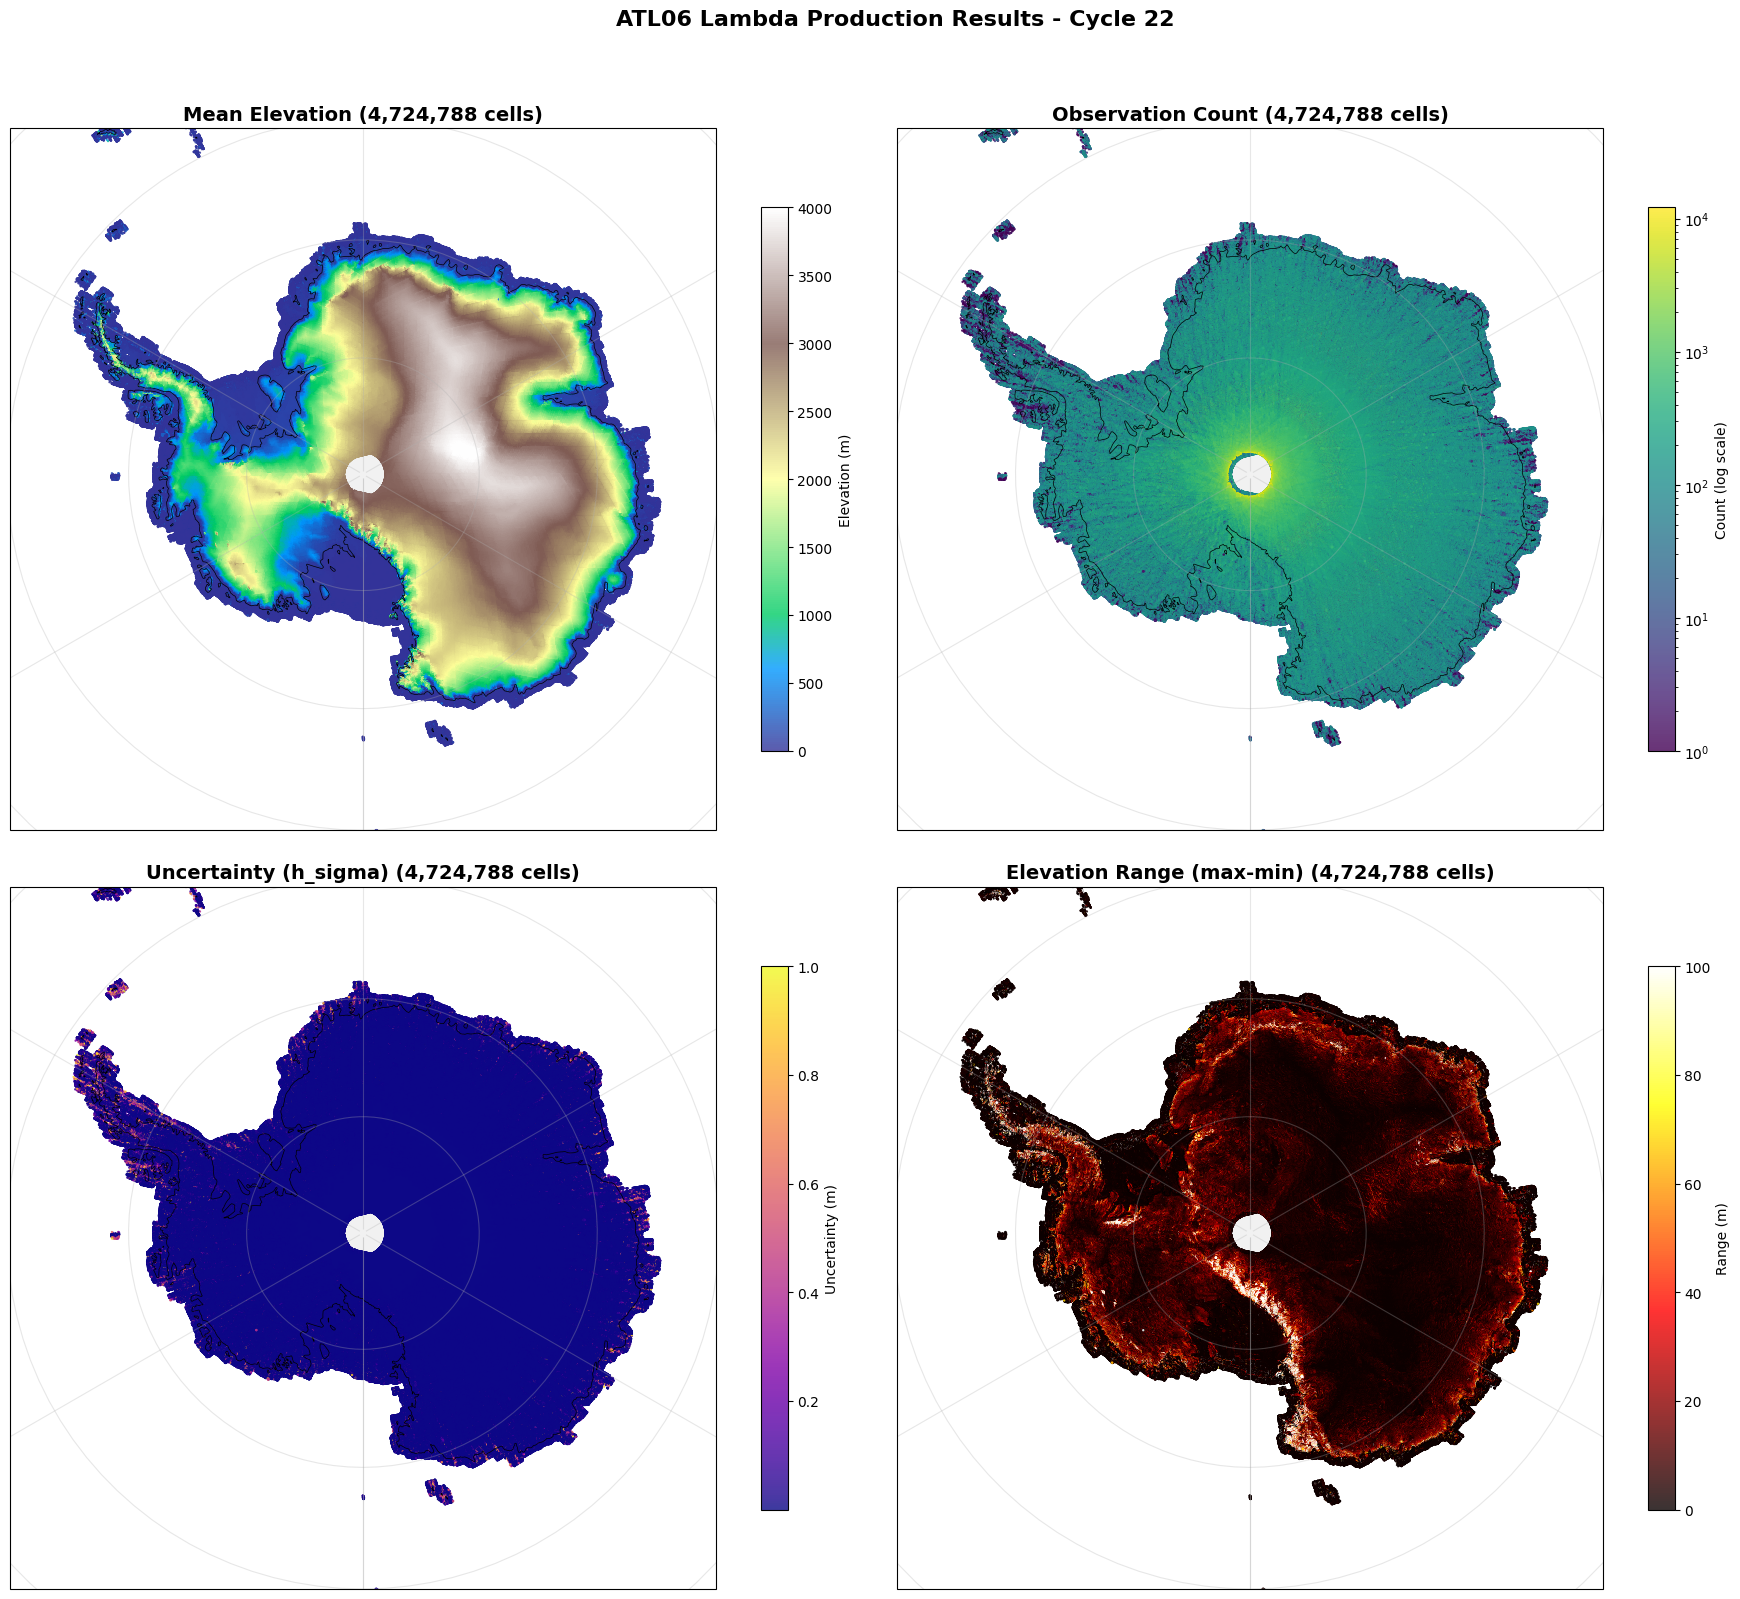

In [11]:
# Antarctic Polar Stereographic projection
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(2, 2, figsize=(18, 16), subplot_kw={"projection": proj})

# Add Antarctic coastline to all subplots
for ax in axes.flat:
    ax.coastlines(resolution="50m", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.gridlines(draw_labels=False, alpha=0.3)
    ax.set_extent([-180, 180, -90, -60], crs=data_crs)

# 1. Mean elevation
ax = axes[0, 0]
valid = ~np.isnan(ds["h_mean"].values)
scatter = ax.scatter(
    ds["longitude"].values[valid],
    ds["latitude"].values[valid],
    c=ds["h_mean"].values[valid],
    s=0.5,
    cmap="terrain",
    alpha=0.8,
    vmin=0,
    vmax=4000,
    transform=data_crs,
)
ax.set_title(f"Mean Elevation ({np.sum(valid):,} cells)", fontsize=14, weight="bold")
plt.colorbar(scatter, ax=ax, label="Elevation (m)", shrink=0.7)

# 2. Observation count
ax = axes[0, 1]
valid = ds["count"].values > 0
scatter = ax.scatter(
    ds["longitude"].values[valid],
    ds["latitude"].values[valid],
    c=ds["count"].values[valid],
    s=0.5,
    cmap="viridis",
    alpha=0.8,
    norm=plt.matplotlib.colors.LogNorm(vmin=1),
    transform=data_crs,
)
ax.set_title(f"Observation Count ({np.sum(valid):,} cells)", fontsize=14, weight="bold")
plt.colorbar(scatter, ax=ax, label="Count (log scale)", shrink=0.7)

# 3. Uncertainty (sigma)
ax = axes[1, 0]
valid = ~np.isnan(ds["h_sigma"].values)
scatter = ax.scatter(
    ds["longitude"].values[valid],
    ds["latitude"].values[valid],
    c=ds["h_sigma"].values[valid],
    s=0.5,
    cmap="plasma",
    alpha=0.8,
    vmax=1.0,
    transform=data_crs,
)
ax.set_title(f"Uncertainty (h_sigma) ({np.sum(valid):,} cells)", fontsize=14, weight="bold")
plt.colorbar(scatter, ax=ax, label="Uncertainty (m)", shrink=0.7)

# 4. Elevation range (max - min)
ax = axes[1, 1]
h_range = ds["h_max"].values - ds["h_min"].values
valid = ~np.isnan(h_range)
scatter = ax.scatter(
    ds["longitude"].values[valid],
    ds["latitude"].values[valid],
    c=h_range[valid],
    s=0.5,
    cmap="hot",
    alpha=0.8,
    vmax=100,
    transform=data_crs,
)
ax.set_title(f"Elevation Range (max-min) ({np.sum(valid):,} cells)", fontsize=14, weight="bold")
plt.colorbar(scatter, ax=ax, label="Range (m)", shrink=0.7)

plt.suptitle("ATL06 Lambda Production Results - Cycle 22", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Histograms

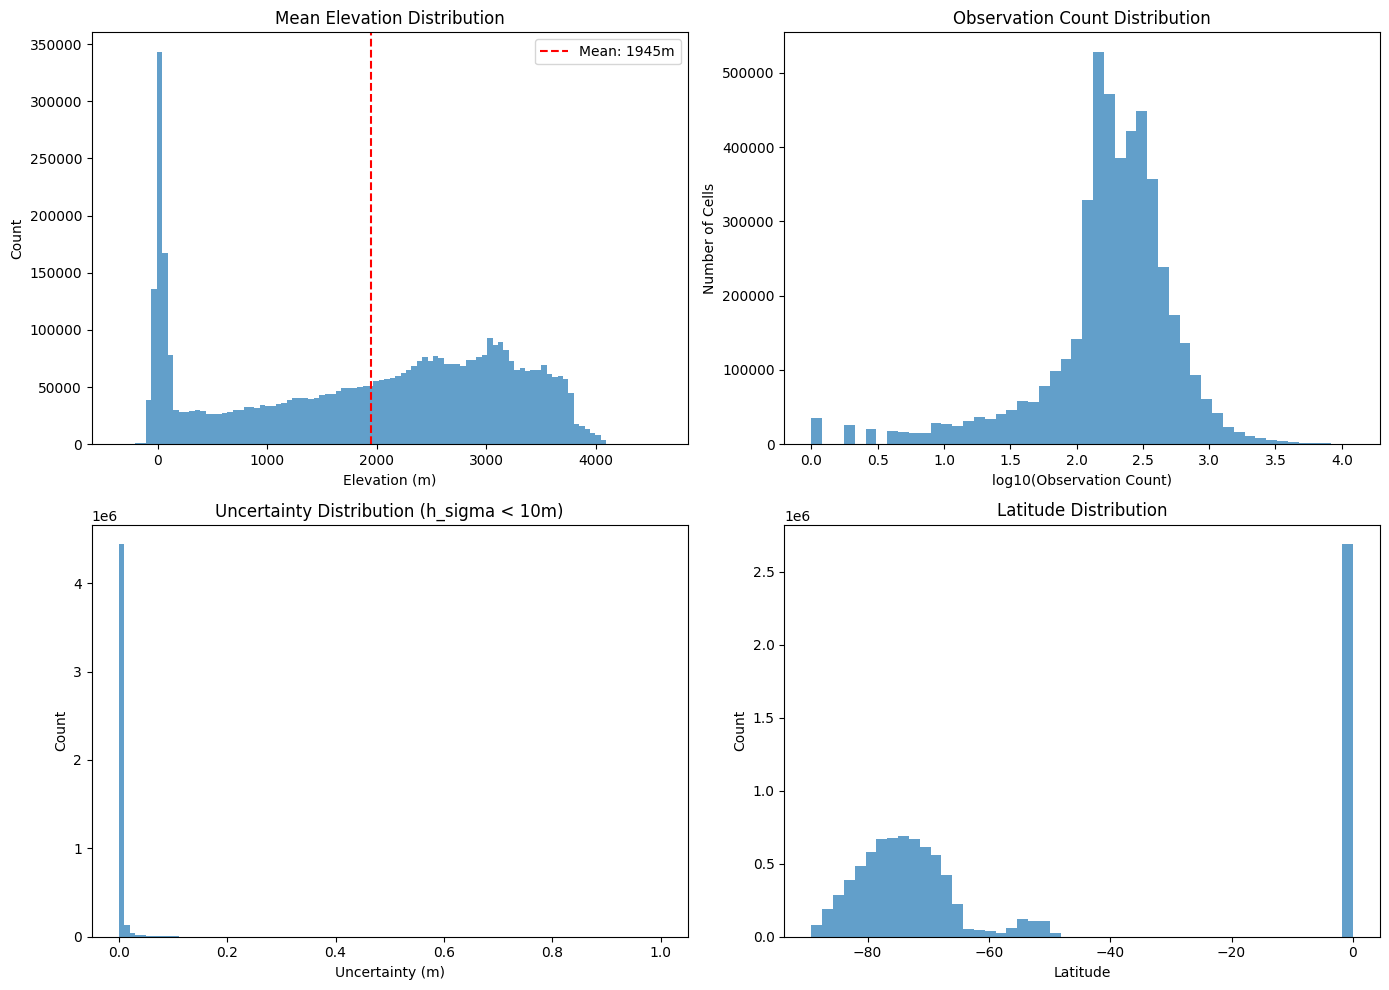

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elevation distribution
ax = axes[0, 0]
valid = ~np.isnan(ds["h_mean"].values)
ax.hist(ds["h_mean"].values[valid], bins=100, edgecolor="none", alpha=0.7)
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Count")
ax.set_title("Mean Elevation Distribution")
ax.axvline(
    ds["h_mean"].mean().values,
    color="red",
    linestyle="--",
    label=f"Mean: {ds['h_mean'].mean().values:.0f}m",
)
ax.legend()

# Observation count distribution (log scale)
ax = axes[0, 1]
valid = ds["count"].values > 0
ax.hist(np.log10(ds["count"].values[valid]), bins=50, edgecolor="none", alpha=0.7)
ax.set_xlabel("log10(Observation Count)")
ax.set_ylabel("Number of Cells")
ax.set_title("Observation Count Distribution")

# Uncertainty distribution
ax = axes[1, 0]
valid = ~np.isnan(ds["h_sigma"].values) & (ds["h_sigma"].values < 10)
ax.hist(ds["h_sigma"].values[valid], bins=100, edgecolor="none", alpha=0.7)
ax.set_xlabel("Uncertainty (m)")
ax.set_ylabel("Count")
ax.set_title("Uncertainty Distribution (h_sigma < 10m)")

# Latitude distribution
ax = axes[1, 1]
ax.hist(ds["latitude"].values, bins=50, edgecolor="none", alpha=0.7)
ax.set_xlabel("Latitude")
ax.set_ylabel("Count")
ax.set_title("Latitude Distribution")

plt.tight_layout()
plt.show()

## 7. Regional Zoom - West Antarctica

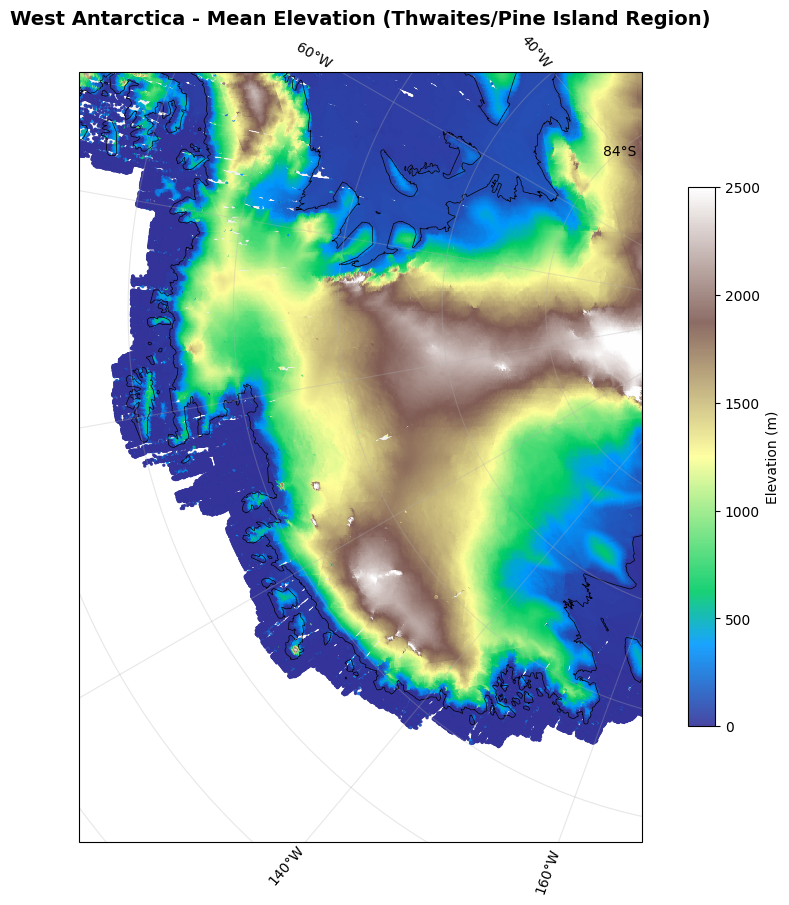

In [13]:
# Zoom into West Antarctica (Thwaites/Pine Island region)
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": proj})

ax.coastlines(resolution="10m", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.gridlines(draw_labels=True, alpha=0.3)

# West Antarctica extent
ax.set_extent([-140, -70, -85, -70], crs=data_crs)

valid = ~np.isnan(ds["h_mean"].values)
scatter = ax.scatter(
    ds["longitude"].values[valid],
    ds["latitude"].values[valid],
    c=ds["h_mean"].values[valid],
    s=2,
    cmap="terrain",
    alpha=0.9,
    vmin=0,
    vmax=2500,
    transform=data_crs,
)

plt.colorbar(scatter, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title(
    "West Antarctica - Mean Elevation (Thwaites/Pine Island Region)", fontsize=14, weight="bold"
)
plt.show()